Reference:

https://arxiv.org/abs/2210.03493

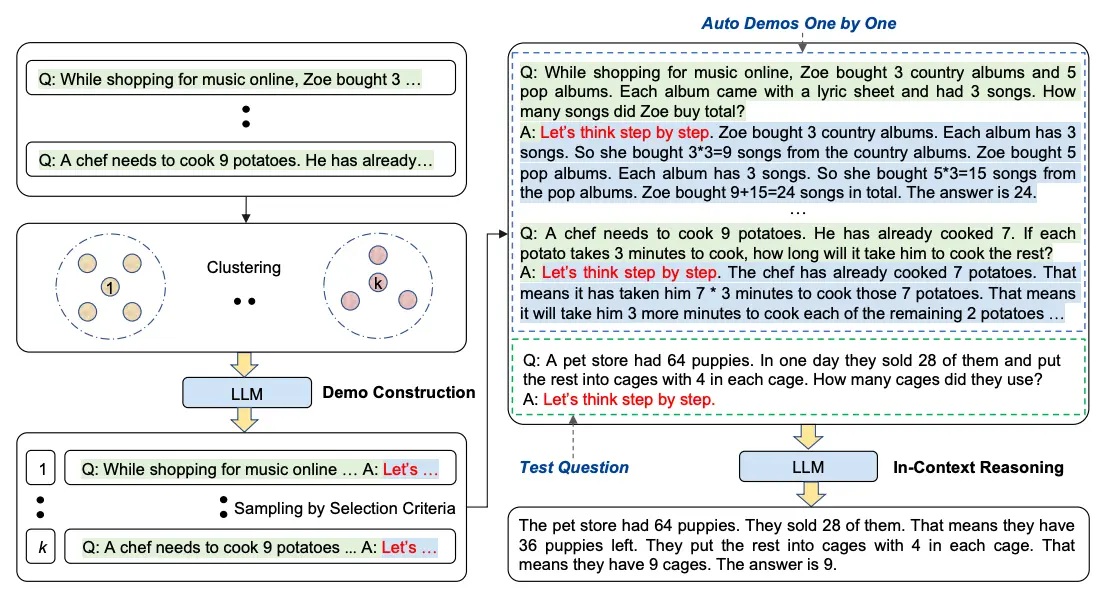

In [ ]:
import os
import random
import json
import time
import random
import re
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from dotenv import load_dotenv
from IPython.display import display, Markdown
from openai import OpenAI

load_dotenv(os.path.join("..", ".env"), override=True)


True

In [2]:
# 1. Definimos la función de semilla aleatoria
def fix_seed(seed=192):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

In [20]:
random_seed = 192
fix_seed(random_seed)
encoder = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# 3. Lectura de datos
corpus = []
question = []
rationale = []
gold_ans = []
pred_ans = []

with open("dataset/multiarith_zero_shot_cot.log", "r", encoding="utf-8") as fp:
    answer_seg = ""
    for line in fp:
        if "Q: " in line:
            c_question = line.strip()

        if "A: " in line:
            answer_seg = line
        elif "Therefore" in line and "the answer" in line:
            c_rationale = answer_seg
        elif answer_seg != "":
            answer_seg += line
        
        if "pred_mode" in line:
            c_pred_ans = line.split(":")[1].strip()
        if "GT :" in line:
            c_gold_ans = line.split(":")[1].strip()

            c_rationale = c_rationale.replace("A: Let's think step by step.", "Let's think step by step.")
            c_question = c_question + "\nA:"

            corpus.append(c_question)
            question.append(c_question)
            rationale.append(c_rationale)
            pred_ans.append(c_pred_ans)
            gold_ans.append(c_gold_ans)
            answer_seg = ""

In [19]:
print(f"CORPUS #{len(corpus)}:\n{corpus}")
print(f"QUESTIONS #{len(question)}:\n{question}")
print(f"REASONING #{len(rationale)}:\n{rationale}")
print(f"PREDICTION #{len(pred_ans)}:\n{pred_ans}")
print(f"RESPONSE (Ground Truth) #{len(gold_ans)}:\n{gold_ans}")

CORPUS #600:
['Q: For Halloween Megan received 11 pieces of candy from neighbors and 5 pieces from her older sister. If she only ate 8 pieces a day, how long would the candy last her?\nA:', 'Q: Bianca and her mom were picking carrots from their garden. Bianca picked 26 and her mother picked 15. If only 16 of the carrots were good, how many bad carrots did they have?\nA:', 'Q: Paige and her friends were recycling paper for their class. For every 4 pounds they recycled they earned one point. If Paige recycled 14 pounds and her friends recycled 2 pounds, how many points did they earn?\nA:', 'Q: In fourth grade there were 4 students at the start of the year. During the year 3 students left and 42 new students came to school. How many students were in fourth grade at the end?\nA:', 'Q: A toy store had 4 giant stuffed bears in stock when they got another shipment with 10 bears in it. The put the bears onto shelves with 7 on each shelf. How many shelves did they use?\nA:', 'Q: Bianca was orga

In [30]:
# 4. Clustering
num_clusters = 8
corpus_embeddings = encoder.encode(corpus)

clustering_model = KMeans(n_clusters=num_clusters, random_state=random_seed, n_init='auto')
clustering_model.fit(corpus_embeddings) # find centroides
cluster_assignment = clustering_model.labels_

clustered_sentences = [[] for i in range(num_clusters)]
clustered_dists = [[] for i in range(num_clusters)]
clustered_idx = [[] for i in range(num_clusters)]

# Calcula la distancia entre cada pregunta y el centroide
distance = clustering_model.transform(corpus_embeddings)

for sentence_id, cluster_id in enumerate(cluster_assignment):
    clustered_sentences[cluster_id].append(corpus[sentence_id])
    clustered_dists[cluster_id].append(distance[sentence_id][cluster_id])
    clustered_idx[cluster_id].append(sentence_id)

In [33]:
# 5. Selección de Ejemplos
sampling = "center"
max_ra_len = 5
task = "multiarith"

demos = []
for i in range(len(clustered_dists)):
    print(f"\nCluster {i+1}:")
    tmp = list(map(list, zip(range(len(clustered_dists[i])), clustered_dists[i])))
    top_min_dist = sorted(tmp, key=lambda x: x[1], reverse=False)
    
    if not sampling == "center":
        random.shuffle(top_min_dist)
        
    for element in top_min_dist:
        min_idx = element[0]
        c_rationale = rationale[clustered_idx[i][min_idx]].strip()
        c_pred_ans = pred_ans[clustered_idx[i][min_idx]].strip()

        # Inicio de la comprobación de calidad del ejemplo seleccionado:
        # Condición 1: La pregunta no debe tener más de 60 palabras.
        # Condición 2: El razonamiento no debe tener más líneas que 'max_ra_len' (5 líneas).
        # Condición 3: El razonamiento debe terminar en un punto ".".
        # Condición 4: La respuesta predicha no debe estar en blanco.
        if len(question[clustered_idx[i][min_idx]].strip().split()) <= 60 \
            and len(c_rationale.replace("\n\n", "\n").split("\n")) <= max_ra_len and c_rationale[-1] == "." and c_pred_ans != "":
            
            if task in ["gsm8k", "multiarith", "singleeq", "addsub", "svamp"]:
                if not (c_pred_ans.strip() in c_rationale.split(".")[-2] or c_pred_ans.strip() in c_rationale.split()[-10:]):
                    continue
                    
            c_question = question[clustered_idx[i][min_idx]]
            c_rationale = c_rationale.replace("\n\n", "\n").replace("\n", " ").strip()
            c_rationale = " ".join(c_rationale.split())
            c_gold_ans = gold_ans[clustered_idx[i][min_idx]]
            
            demo_element = {
                "question": c_question,
                "rationale": c_rationale,
                "pred_ans": c_pred_ans,
                "gold_ans": c_gold_ans,
            }
            demos.append(demo_element)
            print(demo_element)
            break


Cluster 1:
{'question': 'Q: Bianca was organizing her book case making sure each of the shelves had exactly 8 books on it. If she had 5 shelves of mystery books and 4 shelves of picture books, how many books did she have total?\nA:', 'rationale': "Let's think step by step. There are 5 shelves of mystery books. Each shelf has 8 books. So that's 40 mystery books. There are 4 shelves of picture books. Each shelf has 8 books. So that's 32 picture books. 40 + 32 = 72 books.", 'pred_ans': '72', 'gold_ans': '72'}

Cluster 2:
{'question': 'Q: The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, how many apples would they have?\nA:', 'rationale': "Let's think step by step. The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, How many apples would they have? The school cafeteria would have 23 + 6, or 29, apples.", 'pred_ans': '29', 'gold_ans': '9'}

Cluster 3:
{'question': 'Q: For Hallowe

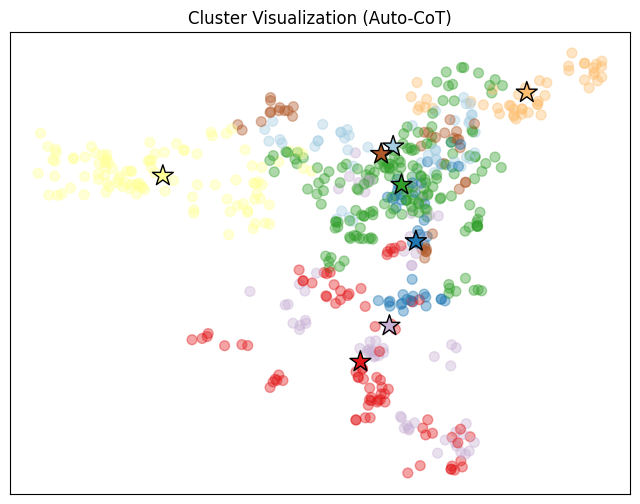

In [34]:
y_km = clustering_model.fit_predict(corpus_embeddings)
pca_model = PCA(n_components=2, random_state=random_seed)
transformed = pca_model.fit_transform(corpus_embeddings)
centers = pca_model.transform(clustering_model.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(x=transformed[:, 0], y=transformed[:, 1], c=y_km, s=50, cmap=plt.cm.Paired, alpha=0.4)
plt.scatter(centers[:, 0], centers[:, 1], s=250, marker='*', label='centroids', edgecolor='black', c=np.arange(0,num_clusters), cmap=plt.cm.Paired)
plt.xticks([])
plt.yticks([])
plt.title("Cluster Visualization (Auto-CoT)")
plt.show()

In [42]:
def create_demo_text(demos_list):
    demo_text = ""
    for d in demos_list:
        # Añade la pregunta, el razonamiento y la respuesta predicha
        demo_text += d['question'] + " " 
        demo_text += d['rationale'] + " "
        demo_text += "Therefore, the answer is " + str(d['pred_ans']) + ".\n\n"
    return demo_text

def extract_answer(text):
    match = re.search(r'([0-9\.]+)(?=[^\d]*$)', text)
    if match:
        return match.group(1)
    return text.strip()

demo_prompt = create_demo_text(demos)
print(demo_prompt)

Q: Bianca was organizing her book case making sure each of the shelves had exactly 8 books on it. If she had 5 shelves of mystery books and 4 shelves of picture books, how many books did she have total?
A: Let's think step by step. There are 5 shelves of mystery books. Each shelf has 8 books. So that's 40 mystery books. There are 4 shelves of picture books. Each shelf has 8 books. So that's 32 picture books. 40 + 32 = 72 books. Therefore, the answer is 72.

Q: The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, how many apples would they have?
A: Let's think step by step. The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, How many apples would they have? The school cafeteria would have 23 + 6, or 29, apples. Therefore, the answer is 29.

Q: For Halloween Katie and her sister combined the candy they received. Katie had 8 pieces of candy while her sister had 23. If they ate 8 pi

In [51]:
# 6. Inferencia
total = 0
correct = 0
results_log = []

client = OpenAI()

with open("dataset/MultiArith.json", "r", encoding="utf-8") as f:
    test_dataset = json.load(f)

samples = random.sample(test_dataset, 2)

for i, data in enumerate(samples):    
    # Preparamos la pregunta actual
    question_text = data['sQuestion']
    ground_truth = str(data['lSolutions'][0]).strip()
    
    # Construimos el input final: Ejemplos + Pregunta Nueva + Activador CoT
    current_prompt = demo_prompt + "Q: " + question_text + "\nA: Let's think step by step."

    response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a helpful assistant that solves math problems step by step."},
                {"role": "user", "content": current_prompt}
            ],
            temperature=0, # Temperatura 0 para respuestas más lógicas y consistentes
            max_tokens=256
        )
    
    # Extraemos el razonamiento generado
    rationale_generated = response.choices[0].message.content
    
    # Limpiamos para obtener solo la respuesta numérica
    pred_ans = extract_answer(rationale_generated)
    
    print("="*60)
    print(f"INPUT: \n {current_prompt}")
    print(f"OUTPUT:")
    display(Markdown(rationale_generated))
    print(f"Predicción: {pred_ans} | Correcta: {ground_truth}")
    time.sleep(1)


INPUT: 
 Q: Bianca was organizing her book case making sure each of the shelves had exactly 8 books on it. If she had 5 shelves of mystery books and 4 shelves of picture books, how many books did she have total?
A: Let's think step by step. There are 5 shelves of mystery books. Each shelf has 8 books. So that's 40 mystery books. There are 4 shelves of picture books. Each shelf has 8 books. So that's 32 picture books. 40 + 32 = 72 books. Therefore, the answer is 72.

Q: The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, how many apples would they have?
A: Let's think step by step. The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, How many apples would they have? The school cafeteria would have 23 + 6, or 29, apples. Therefore, the answer is 29.

Q: For Halloween Katie and her sister combined the candy they received. Katie had 8 pieces of candy while her sister had 23. If they

Let's break it down step by step.

1. The waiter initially had 33 customers.
2. 31 customers left, so we subtract that from the initial number:
   \[
   33 - 31 = 2
   \]
   Now, the waiter has 2 customers left.

3. Then, he got another 26 customers, so we add that to the remaining customers:
   \[
   2 + 26 = 28
   \]

Therefore, the total number of customers the waiter would have is 28. 

Thus, the answer is 28.

Predicción: 28. | Correcta: 28.0
INPUT: 
 Q: Bianca was organizing her book case making sure each of the shelves had exactly 8 books on it. If she had 5 shelves of mystery books and 4 shelves of picture books, how many books did she have total?
A: Let's think step by step. There are 5 shelves of mystery books. Each shelf has 8 books. So that's 40 mystery books. There are 4 shelves of picture books. Each shelf has 8 books. So that's 32 picture books. 40 + 32 = 72 books. Therefore, the answer is 72.

Q: The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, how many apples would they have?
A: Let's think step by step. The school cafeteria had 23 apples. If they used 20 to make lunch for the students and then bought 6 more, How many apples would they have? The school cafeteria would have 23 + 6, or 29, apples. Therefore, the answer is 29.

Q: For Halloween Katie and her sister combined the candy they received. Katie had 8 pieces of candy

Let's break it down step by step.

1. The store initially had 5 oranges in the bin.
2. They threw away 2 old oranges. So, we subtract 2 from 5:
   \[
   5 - 2 = 3
   \]
   Now, there are 3 oranges left in the bin.
3. They then put 28 new oranges in the bin. So, we add 28 to the 3 remaining oranges:
   \[
   3 + 28 = 31
   \]

Therefore, the total number of oranges in the bin is 31. 

The answer is 31.

Predicción: 31. | Correcta: 31.0
